# 02 — Balanced AIA CNN Sanity Year-Holdout Experiment

**Purpose:** Test whether the AIA image-only CNN pipeline learns beyond the tiny canary run.

This is **not a final publication result**. It is a controlled sanity experiment.

## Design

- **Input:** AIA NPZ tensor `x`, shape `(512, 512, 6)`
- **Channels:** `aia94`, `aia131`, `aia171`, `aia193`, `aia211`, `aia335`
- **Label:** `label_48h_final` from the repaired AR-specific manifest
- **Important:** ignore embedded NPZ `y`
- **Train years:** 2010–2013
- **Validation year:** 2014
- **Train subset:** 200 positive + 200 negative
- **Validation subset:** 100 positive + 100 negative
- **Epochs:** 5
- **Batch size:** 8

In [1]:
from pathlib import Path
import hashlib
import json
import subprocess
import random
from datetime import datetime

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

try:
    from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
    SKLEARN_AVAILABLE = True
except Exception as exc:
    print("sklearn metrics unavailable:", repr(exc))
    SKLEARN_AVAILABLE = False

SEED = 42

ROOT = Path.home() / "solar_flare_aia"
MANIFEST = ROOT / "training/final_metadata/baseline_2010_2016_AR_SPECIFIC_manifest.csv"

CACHE_DIR = ROOT / "cache/gcs_npz_sanity"
METRICS_DIR = ROOT / "results/metrics"
MODELS_DIR = ROOT / "results/models"
FIGURES_DIR = ROOT / "results/figures"

for p in [CACHE_DIR, METRICS_DIR, MODELS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

TRAIN_YEARS = [2010, 2011, 2012, 2013]
VAL_YEARS = [2014]

TRAIN_POS = 200
TRAIN_NEG = 200
VAL_POS = 100
VAL_NEG = 100

BATCH_SIZE = 8
EPOCHS = 5
LR = 1e-3
NUM_WORKERS = 0

EXPERIMENT_NAME = "sanity_aia_cnn_year_holdout"

In [2]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA memory GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
else:
    print("WARNING: CUDA is not available. Stop and fix the kernel/environment before training.")

Device: cuda
GPU: NVIDIA L4
CUDA memory GB: 22.06


## 1. Load and audit the baseline manifest

In [3]:
df = pd.read_csv(MANIFEST, low_memory=False)

print("Manifest:", MANIFEST)
print("Rows:", len(df))

required_cols = ["gcp_path", "sample_id", "year", "label_48h_final"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Manifest is missing required columns: {missing_cols}")

print("\nYears:")
print(df["year"].value_counts().sort_index())

print("\nLabels:")
print(df["label_48h_final"].value_counts())

print("\nMissing checks:")
for col in required_cols:
    print(f"{col}: {df[col].isna().sum()} missing")

assert df["gcp_path"].isna().sum() == 0
assert df["sample_id"].isna().sum() == 0
assert df["label_48h_final"].isna().sum() == 0

Manifest: /home/abmoses2000/solar_flare_aia/training/final_metadata/baseline_2010_2016_AR_SPECIFIC_manifest.csv
Rows: 68010

Years:
year
2010     3306
2011    11142
2012    10815
2013    13066
2014    11627
2015    11236
2016     6818
Name: count, dtype: int64

Labels:
label_48h_final
0    65612
1     2398
Name: count, dtype: int64

Missing checks:
gcp_path: 0 missing
sample_id: 0 missing
year: 0 missing
label_48h_final: 0 missing


## 2. Create balanced year-holdout subsets

In [4]:
def make_balanced_subset(df: pd.DataFrame, years, n_pos: int, n_neg: int, seed: int) -> pd.DataFrame:
    part = df[df["year"].isin(years)].copy()
    pos_pool = part[part["label_48h_final"] == 1]
    neg_pool = part[part["label_48h_final"] == 0]

    print(f"Years {years}: available positives={len(pos_pool)}, negatives={len(neg_pool)}")

    if len(pos_pool) < n_pos:
        raise ValueError(f"Not enough positive samples for years {years}: requested {n_pos}, available {len(pos_pool)}")
    if len(neg_pool) < n_neg:
        raise ValueError(f"Not enough negative samples for years {years}: requested {n_neg}, available {len(neg_pool)}")

    pos = pos_pool.sample(n_pos, random_state=seed)
    neg = neg_pool.sample(n_neg, random_state=seed)

    out = pd.concat([pos, neg], axis=0)
    out = out.sample(frac=1, random_state=seed).reset_index(drop=True)
    return out

train_df = make_balanced_subset(df, TRAIN_YEARS, TRAIN_POS, TRAIN_NEG, SEED)
val_df = make_balanced_subset(df, VAL_YEARS, VAL_POS, VAL_NEG, SEED + 1)

print("\nTrain subset labels:")
print(train_df["label_48h_final"].value_counts())
print("\nTrain years:")
print(train_df["year"].value_counts().sort_index())

print("\nValidation subset labels:")
print(val_df["label_48h_final"].value_counts())
print("\nValidation years:")
print(val_df["year"].value_counts().sort_index())

train_samples_path = METRICS_DIR / f"{EXPERIMENT_NAME}_train_samples.csv"
val_samples_path = METRICS_DIR / f"{EXPERIMENT_NAME}_val_samples.csv"

train_df.to_csv(train_samples_path, index=False)
val_df.to_csv(val_samples_path, index=False)

print("\nSaved train sample list:", train_samples_path)
print("Saved val sample list:", val_samples_path)

Years [2010, 2011, 2012, 2013]: available positives=1230, negatives=37099
Years [2014]: available positives=629, negatives=10998

Train subset labels:
label_48h_final
0    200
1    200
Name: count, dtype: int64

Train years:
year
2010     23
2011    122
2012     93
2013    162
Name: count, dtype: int64

Validation subset labels:
label_48h_final
1    100
0    100
Name: count, dtype: int64

Validation years:
year
2014    200
Name: count, dtype: int64

Saved train sample list: /home/abmoses2000/solar_flare_aia/results/metrics/sanity_aia_cnn_year_holdout_train_samples.csv
Saved val sample list: /home/abmoses2000/solar_flare_aia/results/metrics/sanity_aia_cnn_year_holdout_val_samples.csv


## 3. Dataset loader

In [5]:
def cache_gcs_file(gcp_path: str) -> Path:
    safe_name = hashlib.md5(gcp_path.encode()).hexdigest() + ".npz"
    local_path = CACHE_DIR / safe_name

    if not local_path.exists():
        print(f"Downloading: {gcp_path}")
        subprocess.run(["gcloud", "storage", "cp", gcp_path, str(local_path)], check=True)

    return local_path


class AIANPZDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        local_path = cache_gcs_file(row["gcp_path"])

        data = np.load(local_path, allow_pickle=True)

        # Official image tensor: H, W, C = 512, 512, 6
        x = data["x"].astype(np.float32)

        if x.shape != (512, 512, 6):
            raise ValueError(f"Unexpected x shape {x.shape} for sample {row['sample_id']}")

        # Convert to PyTorch: C, H, W = 6, 512, 512
        x = np.transpose(x, (2, 0, 1))

        # Critical: use repaired manifest label, not embedded NPZ y.
        y = np.float32(row["label_48h_final"])

        return torch.from_numpy(x), torch.tensor(y), str(row["sample_id"])

## 4. Build loaders and inspect one batch

In [6]:
train_loader = DataLoader(
    AIANPZDataset(train_df),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    AIANPZDataset(val_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

x_batch, y_batch, sample_ids = next(iter(train_loader))

print("x batch shape:", tuple(x_batch.shape))
print("y batch shape:", tuple(y_batch.shape))
print("y batch:", y_batch.tolist())
print("first sample ids:", list(sample_ids[:3]))
print("x dtype:", x_batch.dtype)
print("x min:", x_batch.min().item())
print("x max:", x_batch.max().item())

assert tuple(x_batch.shape[1:]) == (6, 512, 512)
assert x_batch.dtype == torch.float32

x batch shape: (8, 6, 512, 512)
y batch shape: (8,)
y batch: [1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0]
first sample ids: ['20120315_0036_HARP1461_NOAA11432', '20121024_1536_HARP2144_NOAA11600', '20131029_1712_HARP3326_NOAA11886']
x dtype: torch.float32
x min: 0.0
x max: 1.0


## 5. Define Tiny AIA CNN model

In [7]:
class TinyAIACNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


model = TinyAIACNN().to(device)
test_logits = model(x_batch.to(device))

print(model)
print("\nLogits shape:", tuple(test_logits.shape))
print("Model device:", next(model.parameters()).device)

TinyAIACNN(
  (net): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Dropout(p=0.2, inplace=False)
    (14): Linear(in_features=64, out_features=1, bias=True)
  )
)

Logits shape: (8,)
Model device: cuda:0


## 6. Metrics helpers

In [8]:
def binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    eps = 1e-12

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    f1 = 2 * precision * recall / max(precision + recall, eps)
    tss = recall + specificity - 1

    numerator = 2 * (tp * tn - fp * fn)
    denominator = ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn))
    hss = numerator / max(denominator, eps)

    out = {
        "threshold": float(threshold),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1),
        "tss": float(tss),
        "hss": float(hss),
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }

    if SKLEARN_AVAILABLE:
        if len(np.unique(y_true)) == 2:
            out["roc_auc"] = float(roc_auc_score(y_true, y_prob))
            out["pr_auc"] = float(average_precision_score(y_true, y_prob))
        else:
            out["roc_auc"] = None
            out["pr_auc"] = None
        out["brier"] = float(brier_score_loss(y_true, y_prob))

    return out


def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    y_true, y_prob, sample_ids_all = [], [], []

    with torch.no_grad():
        for x, y, sample_ids in loader:
            x = x.to(device)
            logits = model(x)
            prob = torch.sigmoid(logits).detach().cpu().numpy()

            y_prob.extend(prob.tolist())
            y_true.extend(y.numpy().tolist())
            sample_ids_all.extend(list(sample_ids))

    metrics = binary_metrics(y_true, y_prob, threshold=threshold)
    predictions = pd.DataFrame({
        "sample_id": sample_ids_all,
        "y_true": np.asarray(y_true).astype(int),
        "y_prob": np.asarray(y_prob, dtype=float),
        "y_pred": (np.asarray(y_prob) >= threshold).astype(int),
    })

    return metrics, predictions

## 7. Train sanity model

In [9]:
seed_everything(SEED)

model = TinyAIACNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

history = []

print("Starting training...")
print("Experiment:", EXPERIMENT_NAME)
print("Device:", device)

for epoch in range(1, EPOCHS + 1):
    model.train()
    losses = []

    for step, (x, y, sample_ids) in enumerate(train_loader, 1):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(float(loss.item()))

        if step == 1:
            print(f"Epoch {epoch} first batch x shape:", tuple(x.shape))
            print(f"Epoch {epoch} first batch y:", y.detach().cpu().numpy().tolist())

    train_metrics, _ = evaluate(model, train_loader, device)
    val_metrics, val_preds = evaluate(model, val_loader, device)

    record = {
        "epoch": epoch,
        "train_loss": float(np.mean(losses)),
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
    }
    history.append(record)

    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("Train loss:", record["train_loss"])
    print("Train metrics:", train_metrics)
    print("Val metrics:", val_metrics)

print("\nTraining complete.")

Starting training...
Experiment: sanity_aia_cnn_year_holdout
Device: cuda
Epoch 1 first batch x shape: (8, 6, 512, 512)
Epoch 1 first batch y: [1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0]

Epoch 1/5
Train loss: 0.6312693607807159
Train metrics: {'threshold': 0.5, 'accuracy': 0.6775, 'precision': 0.6651162790697674, 'recall': 0.715, 'specificity': 0.64, 'f1': 0.689156626506024, 'tss': 0.355, 'hss': 0.355, 'tp': 143, 'tn': 128, 'fp': 72, 'fn': 57, 'roc_auc': 0.7570749999999999, 'pr_auc': 0.7358081466630784, 'brier': 0.20410018667933827}
Val metrics: {'threshold': 0.5, 'accuracy': 0.61, 'precision': 0.6057692307692307, 'recall': 0.63, 'specificity': 0.59, 'f1': 0.6176470588235293, 'tss': 0.21999999999999997, 'hss': 0.22, 'tp': 63, 'tn': 59, 'fp': 41, 'fn': 37, 'roc_auc': 0.6516000000000002, 'pr_auc': 0.6218972363121855, 'brier': 0.2315830114760281}
Epoch 2 first batch x shape: (8, 6, 512, 512)
Epoch 2 first batch y: [0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0]

Epoch 2/5
Train loss: 0.60005313515

## 8. Save metrics, predictions, and model

In [10]:
run_timestamp = datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")

train_metrics, train_preds = evaluate(model, train_loader, device)
val_metrics, val_preds = evaluate(model, val_loader, device)

output = {
    "purpose": "Balanced year-holdout sanity experiment; not final publication result",
    "run_timestamp_utc": run_timestamp,
    "experiment_name": EXPERIMENT_NAME,
    "manifest": str(MANIFEST),
    "uses_label": "label_48h_final",
    "ignores_npz_y": True,
    "input_shape_hwc": [512, 512, 6],
    "channels": ["aia94", "aia131", "aia171", "aia193", "aia211", "aia335"],
    "train_years": TRAIN_YEARS,
    "val_years": VAL_YEARS,
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "train_pos": int((train_df["label_48h_final"] == 1).sum()),
    "train_neg": int((train_df["label_48h_final"] == 0).sum()),
    "val_pos": int((val_df["label_48h_final"] == 1).sum()),
    "val_neg": int((val_df["label_48h_final"] == 0).sum()),
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "seed": SEED,
    "model": "TinyAIACNN",
    "final_train_metrics": train_metrics,
    "final_val_metrics": val_metrics,
    "history": history,
}

metrics_path = METRICS_DIR / f"{EXPERIMENT_NAME}_metrics.json"
model_path = MODELS_DIR / f"{EXPERIMENT_NAME}.pt"
train_preds_path = METRICS_DIR / f"{EXPERIMENT_NAME}_train_predictions.csv"
val_preds_path = METRICS_DIR / f"{EXPERIMENT_NAME}_val_predictions.csv"

metrics_path.write_text(json.dumps(output, indent=2))
torch.save(model.state_dict(), model_path)
train_preds.to_csv(train_preds_path, index=False)
val_preds.to_csv(val_preds_path, index=False)

print("Saved metrics:", metrics_path)
print("Saved model:", model_path)
print("Saved train predictions:", train_preds_path)
print("Saved val predictions:", val_preds_path)

/tmp/ipykernel_48939/3819308982.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_timestamp = datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")


Saved metrics: /home/abmoses2000/solar_flare_aia/results/metrics/sanity_aia_cnn_year_holdout_metrics.json
Saved model: /home/abmoses2000/solar_flare_aia/results/models/sanity_aia_cnn_year_holdout.pt
Saved train predictions: /home/abmoses2000/solar_flare_aia/results/metrics/sanity_aia_cnn_year_holdout_train_predictions.csv
Saved val predictions: /home/abmoses2000/solar_flare_aia/results/metrics/sanity_aia_cnn_year_holdout_val_predictions.csv


## 9. Quick learning curve plot

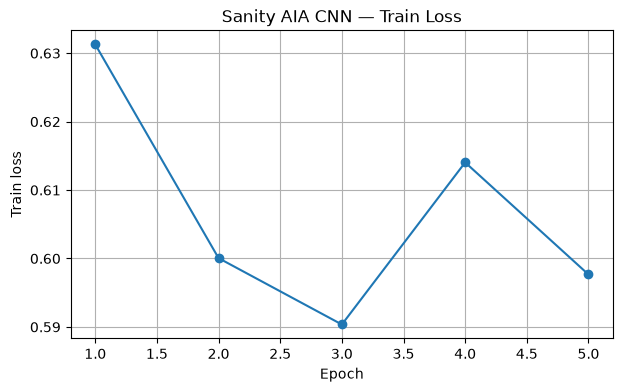

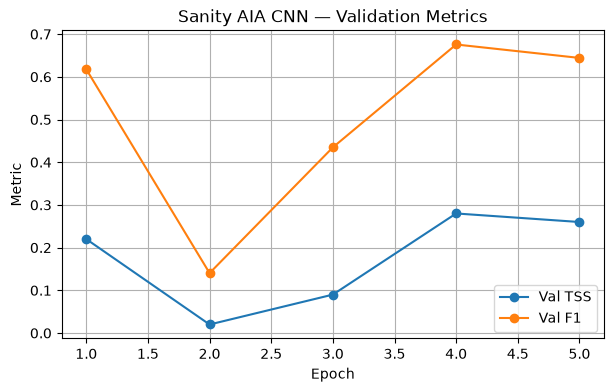

Saved figure: /home/abmoses2000/solar_flare_aia/results/figures/sanity_aia_cnn_year_holdout_train_loss.png
Saved figure: /home/abmoses2000/solar_flare_aia/results/figures/sanity_aia_cnn_year_holdout_val_metrics.png


In [11]:
import matplotlib.pyplot as plt

epochs = [r["epoch"] for r in history]
train_losses = [r["train_loss"] for r in history]
val_tss = [r["val_metrics"]["tss"] for r in history]
val_f1 = [r["val_metrics"]["f1"] for r in history]

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Sanity AIA CNN — Train Loss")
plt.grid(True)
loss_fig = FIGURES_DIR / f"{EXPERIMENT_NAME}_train_loss.png"
plt.savefig(loss_fig, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, val_tss, marker="o", label="Val TSS")
plt.plot(epochs, val_f1, marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Sanity AIA CNN — Validation Metrics")
plt.legend()
plt.grid(True)
metric_fig = FIGURES_DIR / f"{EXPERIMENT_NAME}_val_metrics.png"
plt.savefig(metric_fig, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", loss_fig)
print("Saved figure:", metric_fig)

In [3]:
from pathlib import Path
from IPython.display import display, Markdown
import json
import pandas as pd

ROOT = Path.home() / "solar_flare_aia"
METRICS_DIR = ROOT / "results/metrics"
EXPERIMENT_NAME = "sanity_aia_cnn_year_holdout"

metrics_path = METRICS_DIR / f"{EXPERIMENT_NAME}_metrics.json"

metrics = json.loads(metrics_path.read_text())

rows = []
for item in metrics["history"]:
    row = {
        "epoch": item["epoch"],
        "train_loss": item["train_loss"],
        "train_accuracy": item["train_metrics"]["accuracy"],
        "train_precision": item["train_metrics"]["precision"],
        "train_recall": item["train_metrics"]["recall"],
        "train_f1": item["train_metrics"]["f1"],
        "train_tss": item["train_metrics"]["tss"],
        "train_hss": item["train_metrics"]["hss"],
        "val_accuracy": item["val_metrics"]["accuracy"],
        "val_precision": item["val_metrics"]["precision"],
        "val_recall": item["val_metrics"]["recall"],
        "val_f1": item["val_metrics"]["f1"],
        "val_tss": item["val_metrics"]["tss"],
        "val_hss": item["val_metrics"]["hss"],
        "val_tp": item["val_metrics"]["tp"],
        "val_tn": item["val_metrics"]["tn"],
        "val_fp": item["val_metrics"]["fp"],
        "val_fn": item["val_metrics"]["fn"],
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)

display(Markdown("## Balanced AIA CNN Sanity Experiment — Result Summary"))
display(summary_df)

final_val = metrics["final_val_metrics"]

display(Markdown(f"""
### Final validation result

| Metric | Value |
|---|---:|
| Accuracy | {final_val["accuracy"]:.4f} |
| Precision | {final_val["precision"]:.4f} |
| Recall | {final_val["recall"]:.4f} |
| Specificity | {final_val["specificity"]:.4f} |
| F1 | {final_val["f1"]:.4f} |
| TSS | {final_val["tss"]:.4f} |
| HSS | {final_val["hss"]:.4f} |
| TP | {final_val["tp"]} |
| TN | {final_val["tn"]} |
| FP | {final_val["fp"]} |
| FN | {final_val["fn"]} |

**Important:** This is a balanced year-holdout sanity experiment, not a final publication result.
"""))

summary_path = METRICS_DIR / f"{EXPERIMENT_NAME}_readable_summary.md"

summary_text = f"""# Balanced AIA CNN Sanity Experiment — Result Summary

Purpose: {metrics["purpose"]}

Experiment: {metrics["experiment_name"]}

Train years: {metrics["train_years"]}
Validation years: {metrics["val_years"]}

Train rows: {metrics["train_rows"]}
Validation rows: {metrics["val_rows"]}

Final validation metrics:
- Accuracy: {final_val["accuracy"]:.4f}
- Precision: {final_val["precision"]:.4f}
- Recall: {final_val["recall"]:.4f}
- Specificity: {final_val["specificity"]:.4f}
- F1: {final_val["f1"]:.4f}
- TSS: {final_val["tss"]:.4f}
- HSS: {final_val["hss"]:.4f}
- TP: {final_val["tp"]}
- TN: {final_val["tn"]}
- FP: {final_val["fp"]}
- FN: {final_val["fn"]}

Note: This is not a final publication result.
"""

summary_path.write_text(summary_text)

print("Saved readable summary:", summary_path)

## Balanced AIA CNN Sanity Experiment — Result Summary

,epoch,train_loss,train_accuracy,train_precision,train_recall,train_f1,train_tss,train_hss,val_accuracy,val_precision,val_recall,val_f1,val_tss,val_hss,val_tp,val_tn,val_fp,val_fn
0,1,0.631269,0.6775,0.665116,0.715,0.689157,0.355,0.355,0.610,0.605769,0.63,0.617647,0.22,0.22,63,59,41,37
1,2,0.600053,0.5975,0.800000,0.260,0.392453,0.195,0.195,0.510,0.571429,0.08,0.140351,0.02,0.02,8,94,6,92
2,3,0.590357,0.6725,0.794872,0.465,0.586751,0.345,0.345,0.545,0.573770,0.35,0.434783,0.09,0.09,35,74,26,65
3,4,0.614038,0.7000,0.665289,0.805,0.728507,0.400,0.400,0.640,0.614754,0.75,0.675676,0.28,0.28,75,53,47,25
4,5,0.597666,0.7125,0.737430,0.660,0.696570,0.425,0.425,0.630,0.620370,0.67,0.644231,0.26,0.26,67,59,41,33



### Final validation result

| Metric | Value |
|---|---:|
| Accuracy | 0.6300 |
| Precision | 0.6204 |
| Recall | 0.6700 |
| Specificity | 0.5900 |
| F1 | 0.6442 |
| TSS | 0.2600 |
| HSS | 0.2600 |
| TP | 67 |
| TN | 59 |
| FP | 41 |
| FN | 33 |

**Important:** This is a balanced year-holdout sanity experiment, not a final publication result.


Saved readable summary: /home/abmoses2000/solar_flare_aia/results/metrics/sanity_aia_cnn_year_holdout_readable_summary.md


## 10. GCS backup commands

In [4]:
print(f'''
cd ~/solar_flare_aia

gcloud storage cp notebooks/training/02_balanced_aia_cnn_sanity_year_holdout.ipynb \\
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/metrics/{EXPERIMENT_NAME}_metrics.json \\
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/metrics/{EXPERIMENT_NAME}_train_samples.csv \\
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/metrics/{EXPERIMENT_NAME}_val_samples.csv \\
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/metrics/{EXPERIMENT_NAME}_train_predictions.csv \\
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/metrics/{EXPERIMENT_NAME}_val_predictions.csv \\
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/figures/{EXPERIMENT_NAME}_train_loss.png \\
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/figures/{EXPERIMENT_NAME}_val_metrics.png \\
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/models/{EXPERIMENT_NAME}.pt \\
  gs://suryabench-sharp-pipeline-bamidele/training_models/
''')


cd ~/solar_flare_aia

gcloud storage cp notebooks/training/02_balanced_aia_cnn_sanity_year_holdout.ipynb \
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/metrics/sanity_aia_cnn_year_holdout_metrics.json \
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/metrics/sanity_aia_cnn_year_holdout_train_samples.csv \
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/metrics/sanity_aia_cnn_year_holdout_val_samples.csv \
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/metrics/sanity_aia_cnn_year_holdout_train_predictions.csv \
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/metrics/sanity_aia_cnn_year_holdout_val_predictions.csv \
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

gcloud storage cp results/figures/sanity_aia_cnn_year_holdout_train_loss.png \
  gs://suryabench-sharp-pipeline-bamidele/training_docs/

## 11. GitHub commit commands

Do **not** commit the `.pt` model to GitHub. Commit notebook, metrics, prediction CSVs, and figures only if sizes are reasonable.

```bash
cd ~/solar_flare_aia

git add notebooks/training/02_balanced_aia_cnn_sanity_year_holdout.ipynb
git add results/metrics/sanity_aia_cnn_year_holdout_metrics.json
git add results/metrics/sanity_aia_cnn_year_holdout_train_samples.csv
git add results/metrics/sanity_aia_cnn_year_holdout_val_samples.csv
git add results/metrics/sanity_aia_cnn_year_holdout_train_predictions.csv
git add results/metrics/sanity_aia_cnn_year_holdout_val_predictions.csv
git add results/figures/sanity_aia_cnn_year_holdout_train_loss.png
git add results/figures/sanity_aia_cnn_year_holdout_val_metrics.png

git commit -m "Add balanced AIA CNN year-holdout sanity experiment"
git push
```